shape: (5, 7)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ Fec ┆ Luz ┆ Gas ┆ Ene ┆ Sol ┆ Eol ┆ Ren │
│ ha  ┆ --- ┆ --- ┆ rgi ┆ ar  ┆ ica ┆ ova │
│ --- ┆ f64 ┆ str ┆ a   ┆ --- ┆ --- ┆ ble │
│ str ┆     ┆     ┆ --- ┆ str ┆ str ┆ s   │
│     ┆     ┆     ┆ f64 ┆     ┆     ┆ --- │
│     ┆     ┆     ┆     ┆     ┆     ┆ str │
╞═════╪═════╪═════╪═════╪═════╪═════╪═════╡
│ 201 ┆ 0.0 ┆ nul ┆ 238 ┆ nul ┆ nul ┆ nul │
│ 5-0 ┆ 821 ┆ l   ┆ 91. ┆ l   ┆ l   ┆ l   │
│ 1-0 ┆ 74  ┆     ┆ 201 ┆     ┆     ┆     │
│ 1   ┆     ┆     ┆ 389 ┆     ┆     ┆     │
│ 201 ┆ 0.0 ┆ nul ┆ 282 ┆ nul ┆ nul ┆ nul │
│ 5-0 ┆ 877 ┆ l   ┆ 60. ┆ l   ┆ l   ┆ l   │
│ 1-0 ┆ 78  ┆     ┆ 562 ┆     ┆     ┆     │
│ 2   ┆     ┆     ┆ 5   ┆     ┆     ┆     │
│ 201 ┆ 0.0 ┆ nul ┆ 275 ┆ nul ┆ nul ┆ nul │
│ 5-0 ┆ 835 ┆ l   ┆ 86. ┆ l   ┆ l   ┆ l   │
│ 1-0 ┆ 87  ┆     ┆ 979 ┆     ┆     ┆     │
│ 3   ┆     ┆     ┆ 167 ┆     ┆     ┆     │
│ 201 ┆ 0.0 ┆ nul ┆ 262 ┆ nul ┆ nul ┆ nul │
│ 5-0 ┆ 728 ┆ l   ┆ 35. ┆ l   ┆ l   ┆ l   │
│ 1-0 ┆ 75  ┆     

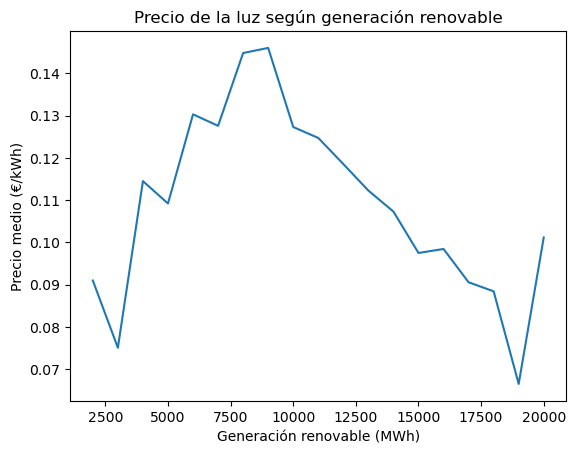

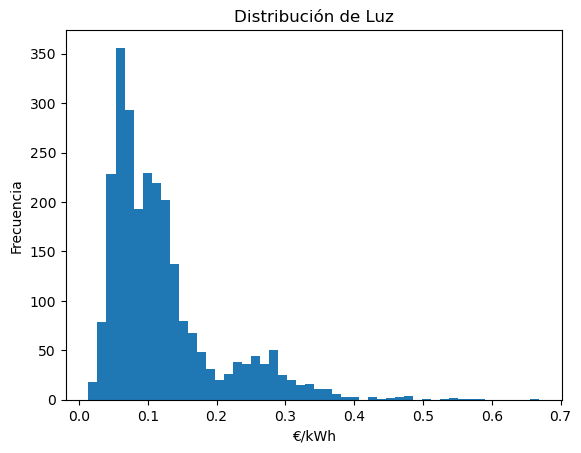

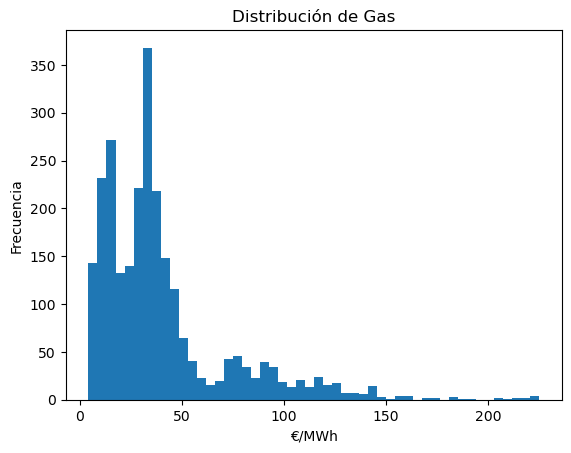

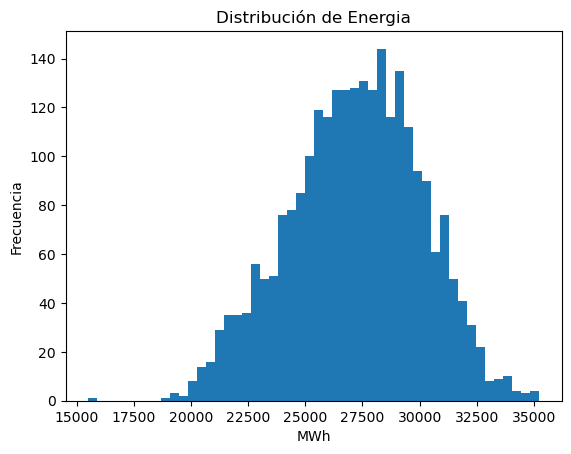

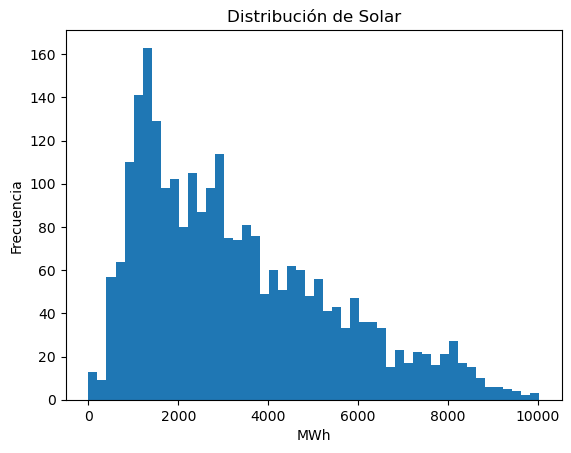

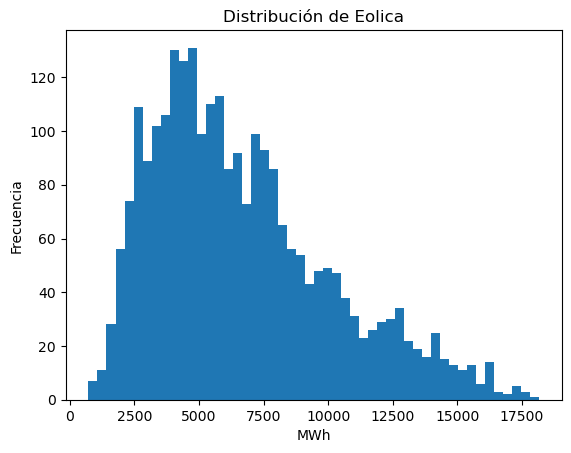


Percentiles Luz:
shape: (1, 2)
┌─────┬─────┐
│ p1  ┆ p99 │
│ --- ┆ --- │
│ f64 ┆ f64 │
╞═════╪═════╡
│ 0.0 ┆ 0.3 │
│ 283 ┆ 809 │
│ 92  ┆ 74  │
└─────┴─────┘

Percentiles Gas:
shape: (1, 2)
┌─────┬─────┐
│ p1  ┆ p99 │
│ --- ┆ --- │
│ f64 ┆ f64 │
╞═════╪═════╡
│ 5.4 ┆ 154 │
│ 8   ┆ .76 │
└─────┴─────┘

Percentiles Energia:
shape: (1, 2)
┌─────┬─────┐
│ p1  ┆ p99 │
│ --- ┆ --- │
│ f64 ┆ f64 │
╞═════╪═════╡
│ 205 ┆ 335 │
│ 70. ┆ 30. │
│ 020 ┆ 743 │
│ 833 ┆ 056 │
└─────┴─────┘


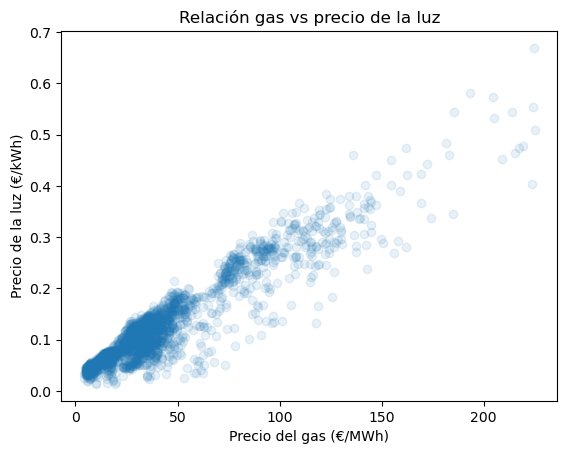

In [47]:
import polars as pl
import matplotlib.pyplot as plt

ruta = "/Users/macbook/ProyectosLocales/PrecioLuz/datos/limpio_total.csv"

df = pl.read_csv(ruta)

print(df.head())
print("Filas:", df.height)
print("Tipos:", df.dtypes)
print("Nulos:", df.null_count())

# rango fechas
print("Rango fechas:", df["Fecha"].min(), df["Fecha"].max())

# inicio de variables
print("\nInicio de cada variable:")
for col in df.columns:
    if col != "Fecha":
        inicio = df.filter(pl.col(col).is_not_null())["Fecha"].min()
        print(col, ":", inicio)

# recorte
df = df.filter(pl.col("Fecha") >= "2018-12-28")

# tipos
df = df.with_columns([
    pl.col("Gas").cast(pl.Float64),
    pl.col("Solar").cast(pl.Float64),
    pl.col("Eolica").cast(pl.Float64),
    pl.col("Renovables").cast(pl.Float64)
])

print("\nEstadísticos:")
print(df.describe())

# correlaciones
print("\nCorrelaciones:")
print(df.drop("Fecha").corr())

# fecha
df = df.with_columns(
    pl.col("Fecha").str.strptime(pl.Date, "%Y-%m-%d")
)

# variables temporales
df = df.with_columns([
    pl.col("Fecha").dt.year().alias("anio"),
    pl.col("Fecha").dt.month().alias("mes"),
    pl.col("Fecha").dt.weekday().alias("dia")
])

# medias
print("\nPrecio medio por día de la semana:")
print(
    df.group_by("dia")
    .agg(pl.col("Luz").mean().alias("precio_medio_eur_kWh"))
    .sort("dia")
)

print("\nPrecio medio por mes:")
print(
    df.group_by("mes")
    .agg(pl.col("Luz").mean().alias("precio_medio_eur_kWh"))
    .sort("mes")
)

# correlación clave
print("\nCorrelación renovables vs precio luz:")
print(df.select(pl.corr("Renovables", "Luz").alias("corr")))

# renovables vs precio
df_bins = df.with_columns(
    (pl.col("Renovables") // 1000 * 1000).alias("grupo_renovables_MWh")
)

df_plot = df_bins.group_by("grupo_renovables_MWh").agg(
    pl.col("Luz").mean().alias("precio_medio_eur_kWh")
).sort("grupo_renovables_MWh")

plt.figure()
plt.plot(
    df_plot["grupo_renovables_MWh"].to_list(),
    df_plot["precio_medio_eur_kWh"].to_list()
)
plt.xlabel("Generación renovable (MWh)")
plt.ylabel("Precio medio (€/kWh)")
plt.title("Precio de la luz según generación renovable")
plt.show()

# histogramas
for col in ["Luz", "Gas", "Energia", "Solar", "Eolica"]:
    plt.figure()
    plt.hist(df[col].to_list(), bins=50)
    plt.title(f"Distribución de {col}")
    if col == "Luz":
        plt.xlabel("€/kWh")
    elif col == "Gas":
        plt.xlabel("€/MWh")
    else:
        plt.xlabel("MWh")
    plt.ylabel("Frecuencia")
    plt.show()

# percentiles
for col in ["Luz", "Gas", "Energia"]:
    print(f"\nPercentiles {col}:")
    print(df.select([
        pl.col(col).quantile(0.01).alias("p1"),
        pl.col(col).quantile(0.99).alias("p99")
    ]))

# scatter gas vs luz
plt.figure()
plt.scatter(
    df["Gas"].to_list(),
    df["Luz"].to_list(),
    alpha=0.1
)
plt.xlabel("Precio del gas (€/MWh)")
plt.ylabel("Precio de la luz (€/kWh)")
plt.title("Relación gas vs precio de la luz")
plt.show()

# guardar
df.write_csv("/Users/macbook/ProyectosLocales/PrecioLuz/datos/datos_limpios.csv")